# AutoCompose


## Import Section


In [1]:
import os
os.chdir("C:/Users/KTS-WS-2501/Documents/Composer-py")
os.getcwd()

'C:\\Users\\KTS-WS-2501\\Documents\\Composer-py'

In [2]:
import torch
torch.manual_seed(64)

In [3]:
import json
import os
import time
from datetime import timedelta
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from torch.optim import AdamW
from torch.utils.data import Dataset, random_split, DataLoader, RandomSampler, SequentialSampler
from transformers import GPT2LMHeadModel, GPT2Tokenizer, get_linear_schedule_with_warmup, DataCollatorWithPadding

c:\Users\KTS-WS-2501\Documents\composer-py\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## GPU Check


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
torch.cuda.mem_get_info(device=0)

(5318377472, 6438780928)

In [7]:
print(f"Device name: {torch.cuda.get_device_name(0)}")
props = torch.cuda.get_device_properties(0)
print(f"Total Memory (GB): {props.total_memory / 1024 ** 3}")

Device name: NVIDIA GeForce RTX 4050 Laptop GPU
Total Memory (GB): 5.99658203125


In [8]:
print(f"Allocated: {torch.cuda.memory_allocated() / 1024 ** 3}GB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1024 ** 3}GB")

Allocated: 0.0GB
Reserved: 0.0GB


## Load tokenizer and model


In [9]:
model_name = "gpt2"

In [10]:
bos_token = "<|startoftext|>"

In [11]:
# tokenizer = GPT2Tokenizer.from_pretrained(
#     model_name,
#     bos_token=bos_token,
#     eos_token=eos_token,
#     pad_token=pad_token
# )

In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained(model_name,bos_token=bos_token)
model = GPT2LMHeadModel.from_pretrained(model_name)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7501.87it/s]


In [14]:
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
tokenizer.add_special_tokens({'bos_token': '<|startoftext|>'})
model.resize_token_embeddings(len(tokenizer))

In [15]:
tokenizer.bos_token_id

50256

In [16]:
tokenizer.special_tokens_map

{'bos_token': '<|startoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '<|endoftext|>'}

In [17]:
len(tokenizer)

50257

In [18]:
model.config.eos_token_id

50256

In [19]:
print(model.transformer.wte.weight.shape)

torch.Size([50257, 768])


In [20]:
print(model.get_input_embeddings().weight.shape)

torch.Size([50257, 768])


In [21]:
len(tokenizer)

50257

In [22]:
model.config.vocab_size

50257

In [24]:
model = model.to(device)

## Data Preparation


In [25]:
data_dir = "data"
file_path = "anticipation.json"

In [26]:
file_full_path = os.path.normpath(os.path.join(data_dir, file_path))

In [27]:
with open(file_full_path, "r") as f:
    data = json.load(f)

data[:5]

[{'poem': 'Though the birds sang gayly to him,\nThough the wild-flowers of the meadow\nFilled the air with odors for him;\nThough the forests and the rivers\nSang and shouted at his coming,\nStill his heart was sad within him,\nFor he was alone in heaven.',
  'id': 26},
 {'poem': 'Rise up from your bed of branches,\nRise, O youth, and wrestle with me!"\nFaint with famine, Hiawatha\nStarted from his bed of branches,\nFrom the twilight of his wigwam\nForth into the flush of sunset\nCame, and wrestled with Mondamin;\nAt his touch he felt new courage\nThrobbing in his brain and bosom,\nFelt new life and hope and vigor\nRun through every nerve and fibre.',
  'id': 93},
 {'poem': 'On the morrow and the next day,\nWhen the sun through heaven descending,\nLike a red and burning cinder\nFrom the hearth of the Great Spirit,\nFell into the western waters,\nCame Mondamin for the trial,\nFor the strife with Hiawatha;\nCame as silent as the dew comes,\nFrom the empty air appearing,\nInto empty air r

In [28]:
data[0].keys()

dict_keys(['poem', 'id'])

Size of dataset


In [29]:
print(f"Train samples len: {len(data)}")

Train samples len: 28956


Check dataset


In [30]:
for i in range(3):
    print(data[i])

{'poem': 'Though the birds sang gayly to him,\nThough the wild-flowers of the meadow\nFilled the air with odors for him;\nThough the forests and the rivers\nSang and shouted at his coming,\nStill his heart was sad within him,\nFor he was alone in heaven.', 'id': 26}
{'poem': 'Rise up from your bed of branches,\nRise, O youth, and wrestle with me!"\nFaint with famine, Hiawatha\nStarted from his bed of branches,\nFrom the twilight of his wigwam\nForth into the flush of sunset\nCame, and wrestled with Mondamin;\nAt his touch he felt new courage\nThrobbing in his brain and bosom,\nFelt new life and hope and vigor\nRun through every nerve and fibre.', 'id': 93}
{'poem': 'On the morrow and the next day,\nWhen the sun through heaven descending,\nLike a red and burning cinder\nFrom the hearth of the Great Spirit,\nFell into the western waters,\nCame Mondamin for the trial,\nFor the strife with Hiawatha;\nCame as silent as the dew comes,\nFrom the empty air appearing,\nInto empty air returning,

Verify Tokenization


In [31]:
sample = data[0]['poem']
print(f"Sample data: {sample}")
sample_ids = tokenizer.encode(sample)
print(f"Sample text ids: {sample_ids}")
sample_decoded = tokenizer.decode(sample_ids)
print(f"Tokenizer decoded: {sample_decoded}")
print(f"Verify tokenizer: {sample == sample_decoded}")

Sample data: Though the birds sang gayly to him,
Though the wild-flowers of the meadow
Filled the air with odors for him;
Though the forests and the rivers
Sang and shouted at his coming,
Still his heart was sad within him,
For he was alone in heaven.
Sample text ids: [10915, 262, 10087, 25889, 5650, 306, 284, 683, 11, 198, 10915, 262, 4295, 12, 2704, 3618, 286, 262, 502, 4584, 198, 37, 2967, 262, 1633, 351, 16298, 669, 329, 683, 26, 198, 10915, 262, 17039, 290, 262, 18180, 198, 50, 648, 290, 17293, 379, 465, 2406, 11, 198, 9590, 465, 2612, 373, 6507, 1626, 683, 11, 198, 1890, 339, 373, 3436, 287, 9538, 13]
Tokenizer decoded: Though the birds sang gayly to him,
Though the wild-flowers of the meadow
Filled the air with odors for him;
Though the forests and the rivers
Sang and shouted at his coming,
Still his heart was sad within him,
For he was alone in heaven.
Verify tokenizer: True


In [32]:
tokenizer("hello", truncation=True, max_length=10, padding="max_length")

{'input_ids': [31373, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256], 'attention_mask': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

In [33]:
tokenizer.eos_token

'<|endoftext|>'

In [34]:
class PoemDataLoader(Dataset):
    def __init__(self, poems, tokenizer, max_len=512):
        self.attn_mask = []
        self.input_ids = []

        for poem in poems:

            encodings_dict = tokenizer(
                "<|startoftext|>"+poem+"<|endoftext|>", max_length=max_len, truncation=True, padding=False)
            self.input_ids.append(torch.tensor(encodings_dict["input_ids"]))
            self.attn_mask.append(torch.tensor(
                encodings_dict["attention_mask"]))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {"input_ids": self.input_ids[idx], "attention_mask": self.attn_mask[idx]}

In [35]:
poems_text = [poem["poem"] for poem in data]
len(poems_text)

28956

In [36]:
poem_data_loader = PoemDataLoader(
    poems=poems_text, max_len=256, tokenizer=tokenizer)

In [37]:
for d in poem_data_loader:
    print(d)
    break

{'input_ids': tensor([   27,    91,  9688,  1659,  5239,    91,    29, 10915,   262, 10087,
        25889,  5650,   306,   284,   683,    11,   198, 10915,   262,  4295,
           12,  2704,  3618,   286,   262,   502,  4584,   198,    37,  2967,
          262,  1633,   351, 16298,   669,   329,   683,    26,   198, 10915,
          262, 17039,   290,   262, 18180,   198,    50,   648,   290, 17293,
          379,   465,  2406,    11,   198,  9590,   465,  2612,   373,  6507,
         1626,   683,    11,   198,  1890,   339,   373,  3436,   287,  9538,
           13, 50256]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


In [38]:
lengths = []

for poem_data in poem_data_loader:
    length = poem_data["attention_mask"].sum().item()
    lengths.append(length)

print(lengths)
print(f"Min length : {min(lengths)}")
print(f"Max length : {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.2f}")

[72, 113, 117, 213, 87, 100, 160, 229, 89, 66, 101, 68, 57, 72, 137, 92, 256, 31, 89, 31, 141, 83, 73, 115, 91, 129, 34, 151, 34, 157, 256, 143, 55, 180, 151, 95, 237, 78, 93, 256, 100, 164, 63, 256, 41, 161, 200, 56, 72, 98, 81, 179, 105, 256, 244, 163, 256, 48, 107, 117, 120, 132, 68, 221, 256, 77, 91, 220, 131, 131, 93, 51, 121, 57, 186, 92, 83, 45, 165, 256, 256, 45, 55, 64, 256, 256, 93, 178, 59, 48, 191, 95, 182, 256, 89, 113, 89, 97, 84, 128, 256, 75, 42, 197, 54, 71, 89, 92, 160, 121, 156, 102, 250, 233, 70, 154, 148, 256, 131, 48, 256, 107, 125, 95, 256, 85, 213, 256, 49, 114, 195, 117, 44, 152, 139, 256, 246, 43, 135, 55, 49, 203, 148, 143, 65, 183, 141, 93, 39, 102, 143, 256, 57, 41, 72, 182, 57, 202, 256, 105, 125, 120, 48, 53, 190, 121, 256, 256, 60, 46, 71, 56, 256, 84, 40, 39, 95, 75, 166, 42, 111, 46, 65, 84, 154, 105, 52, 50, 43, 131, 31, 43, 127, 54, 59, 88, 41, 38, 53, 50, 42, 40, 43, 50, 38, 40, 41, 45, 42, 42, 44, 74, 89, 44, 90, 41, 171, 81, 47, 88, 66, 192, 76, 9

In [39]:
lengths = np.array(lengths)

print("P50:", np.percentile(lengths, 50))
print("P90:", np.percentile(lengths, 90))
print("P95:", np.percentile(lengths, 95))
print("P99:", np.percentile(lengths, 99))

P50: 73.0
P90: 185.0
P95: 253.0
P99: 256.0


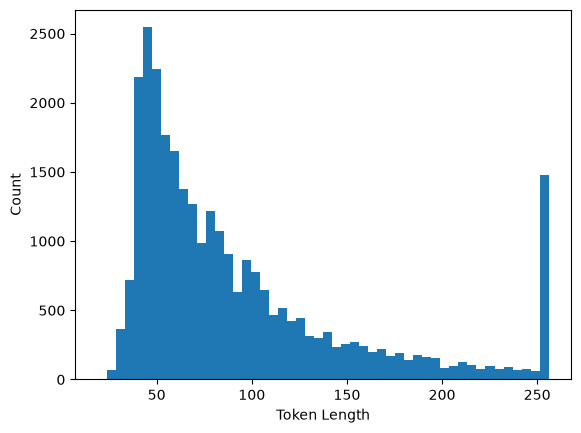

In [40]:
plt.hist(lengths, bins=50)
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.show()

In [41]:
epochs = 3
warmup_steps = 100
sample_every = 100
batch_size = 4
gradient_accumulation_steps = 16
save_steps = 1000

In [42]:
train_size = int(0.95 * len(data))
val_size = len(data) - train_size

In [43]:
train_data, val_data = random_split(poem_data_loader, [train_size, val_size])

In [44]:
data_collector = DataCollatorWithPadding(
    tokenizer=tokenizer, pad_to_multiple_of=8)

In [45]:
for d in train_data:
    print(d)
    break

{'input_ids': tensor([   27,    91,  9688,  1659,  5239,    91,    29,  1890, 21682,  2236,
         9629,   262, 20354,   757,    26,   198, 15316,   262,   698,   436,
         1586,  3687,  2236,  6611,   438,   198,  1199,  1901,   257,  2330,
        20218,   395,   832,   262,  1278,   268,    11,   198,  1870,  3440,
          262,   279,  1127,   351,  6729,    13, 50256]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


In [46]:
train_data_loader = DataLoader(train_data, batch_size=batch_size, sampler=RandomSampler(
    train_data), collate_fn=data_collector)
val_data_loader = DataLoader(val_data, batch_size=batch_size,
                             sampler=SequentialSampler(val_data), collate_fn=data_collector)

In [47]:
train_data_loader

In [48]:
optimizer = AdamW(model.parameters(), lr=5e-5, eps=1e-8)
total_training_steps = len(train_data_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_training_steps)

In [49]:
def format_time(elapsed): return str(timedelta(seconds=int(round(elapsed))))

In [50]:
model.config.vocab_size

50257

In [51]:
print("Tokenizer size:", len(tokenizer))
print("Model vocab size:", model.config.vocab_size)

sample = poem_data_loader.input_ids[0]
print(max(sample))

Tokenizer size: 50257
Model vocab size: 50257
tensor(50256)


In [52]:
for step, batch in enumerate(train_data_loader):
    print(batch)
    break

{'input_ids': tensor([[   27,    91,  9688,  1659,  5239,    91,    29, 23722,   339,    11,
          3025,  3173,   262,  5801, 31733, 11007,    11,   198, 24564,  4892,
           393,  4259,   530,  3356,   286,   465,  2000,    30,   198,  8241,
          2497,   663, 12252,   994,  4485,    11,   290,   612, 15350,    11,
           198, 18438,   391,   465,   898,  3726,    11,   393,   465,   886,
            30,   198,  2348,   292,    11,   644,  4240,     0,   582,   338,
          9098,   636,   198,  3118, 26752,   743,  4485,    11,   290, 12080,
           422,  1242,   284,  1242,    26,   198,  1537,   618,   465,   898,
          1049,   670,   318,   475,  9258,    11,   198,  2061,  1738,   356,
          3080,    11,   416,  7506,   318, 45171,    13, 50256, 50256, 50256,
         50256, 50256, 50256, 50256],
        [   27,    91,  9688,  1659,  5239,    91,    29,  1870,   422,   511,
         20237,   262,  9896,  8278,    11,   290,   836,    77,  1549,   198,


In [53]:
print("Embedding vocab:",
      model.get_input_embeddings().num_embeddings)

Embedding vocab: 50257


In [54]:
for step, batch in enumerate(train_data_loader):
    b_input_ids = batch["input_ids"].to(device)
    b_labels = batch["input_ids"].to(device)
    b_masks = batch["attention_mask"].to(device)
    if b_input_ids.min().item() < 0:
        print(f"Step: {step}Min token:", b_input_ids.min().item())
    if b_input_ids.max().item() >= model.get_input_embeddings().num_embeddings:
        print(f"Step: {step}Max token:", b_input_ids.max().item())

In [55]:
model.config.n_positions

1024

Overfitting test


In [56]:
# for step, batch in enumerate(train_data_loader):
#     b_input_ids = batch["input_ids"].to(device)
#     b_labels[b_masks == 0] = -100
#     b_labels = batch["input_ids"].to(device)
#     b_masks = batch["attention_mask"].to(device)
#     break

In [57]:
# tokenizer.decode(batch["input_ids"])

In [58]:
# for epoch in range(1000):
#     outputs = model(b_input_ids,labels=b_labels,attention_mask=b_masks)
#     loss = outputs[0]
#     print(f"For epoch: {epoch} loss is: {loss}")
#     loss.backward()
#     optimizer.step()
#     scheduler.step()
#     optimizer.zero_grad()

In [59]:
scaler = torch.amp.GradScaler()

In [60]:
for epoch in range(epochs):
    t0 = time.perf_counter()
    total_train_loss = 0
    model.train()
    optimizer.zero_grad()
    for step, batch in enumerate(train_data_loader):            

        b_input_ids = batch["input_ids"].to(device)
        b_masks = batch["attention_mask"].to(device)
        b_labels = b_input_ids.clone()
        b_labels[b_masks == 0] = -100

        with torch.amp.autocast(device_type="cuda",dtype=torch.float16):
            outputs = model(b_input_ids, labels=b_labels, attention_mask=b_masks)
            loss = outputs[0] / gradient_accumulation_steps

        scaler.scale(loss).backward()

        batch_loss = loss.item()
        total_train_loss += batch_loss

        if (step + 1) % sample_every == 0:
            elapsed = time.perf_counter() - t0
            print(f"Epoch {epoch} | Batch {step} of {len(train_data_loader)}. Loss: {batch_loss:.4f}. Time: {elapsed:.2f}s")

        if (step + 1) % gradient_accumulation_steps == 0 or (step + 1) == len(train_data_loader):
            scaler.unscale_(optimizer=optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0, foreach=True)
            
            scaler.step(optimizer=optimizer)
            scaler.update()

            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % save_steps == 0:
            model.save_pretrained("checkpoint/autocompose_model")
            tokenizer.save_pretrained("checkpoint/autocompose_tokenizer")
            print(f"Saved checkpoint to checkpoint")

        model.eval()

        total_val_loss = 0

    with torch.no_grad():
        for val_step, val_batch in enumerate(val_data_loader):
            v_input_ids = val_batch["input_ids"].to(device)
            v_masks = val_batch["attention_mask"].to(device)

            v_labels = v_input_ids.clone()
            v_labels[v_masks == 0] = -100

            with torch.amp.autocast(device_type="cuda",dtype=torch.float16):
                outputs = model(v_input_ids, labels=v_labels, attention_mask=v_masks)
                total_val_loss += outputs[0]

    avg_val_loss = total_val_loss / len(val_data_loader)
    print(f"Epoch {epoch} Evaluation Complete. Average Val Loss: {avg_val_loss:.4f}")

    model.train()
        

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 0 | Batch 99 of 6877. Loss: 0.2872. Time: 10.12s
Epoch 0 | Batch 199 of 6877. Loss: 0.2947. Time: 19.45s
Epoch 0 | Batch 299 of 6877. Loss: 0.2724. Time: 28.80s
Epoch 0 | Batch 399 of 6877. Loss: 0.2920. Time: 38.40s
Epoch 0 | Batch 499 of 6877. Loss: 0.2178. Time: 47.78s
Epoch 0 | Batch 599 of 6877. Loss: 0.2760. Time: 57.51s
Epoch 0 | Batch 699 of 6877. Loss: 0.2607. Time: 66.90s
Epoch 0 | Batch 799 of 6877. Loss: 0.2553. Time: 76.81s
Epoch 0 | Batch 899 of 6877. Loss: 0.2586. Time: 86.15s
Epoch 0 | Batch 999 of 6877. Loss: 0.2277. Time: 94.94s


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.18it/s]


Saved checkpoint to checkpoint
Epoch 0 | Batch 1099 of 6877. Loss: 0.2537. Time: 104.97s
Epoch 0 | Batch 1199 of 6877. Loss: 0.2655. Time: 113.84s
Epoch 0 | Batch 1299 of 6877. Loss: 0.2598. Time: 122.84s
Epoch 0 | Batch 1399 of 6877. Loss: 0.2436. Time: 132.02s
Epoch 0 | Batch 1499 of 6877. Loss: 0.2759. Time: 141.38s
Epoch 0 | Batch 1599 of 6877. Loss: 0.2157. Time: 150.44s
Epoch 0 | Batch 1699 of 6877. Loss: 0.2353. Time: 159.93s
Epoch 0 | Batch 1799 of 6877. Loss: 0.2295. Time: 168.78s
Epoch 0 | Batch 1899 of 6877. Loss: 0.2591. Time: 177.93s
Epoch 0 | Batch 1999 of 6877. Loss: 0.2736. Time: 187.30s


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.93it/s]


...

Saved checkpoint to checkpoint
Epoch 2 | Batch 4099 of 6877. Loss: 0.2442. Time: 367.23s
Epoch 2 | Batch 4199 of 6877. Loss: 0.2405. Time: 375.78s
Epoch 2 | Batch 4299 of 6877. Loss: 0.2125. Time: 385.14s
Epoch 2 | Batch 4399 of 6877. Loss: 0.2381. Time: 394.11s
Epoch 2 | Batch 4499 of 6877. Loss: 0.2382. Time: 403.68s
Epoch 2 | Batch 4599 of 6877. Loss: 0.2391. Time: 412.88s
Epoch 2 | Batch 4699 of 6877. Loss: 0.2128. Time: 421.66s
Epoch 2 | Batch 4799 of 6877. Loss: 0.2364. Time: 430.78s
Epoch 2 | Batch 4899 of 6877. Loss: 0.2149. Time: 439.77s
Epoch 2 | Batch 4999 of 6877. Loss: 0.2265. Time: 448.75s


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s]


Saved checkpoint to checkpoint
Epoch 2 | Batch 5099 of 6877. Loss: 0.2081. Time: 457.95s
Epoch 2 | Batch 5199 of 6877. Loss: 0.1975. Time: 467.28s
Epoch 2 | Batch 5299 of 6877. Loss: 0.2274. Time: 476.50s
Epoch 2 | Batch 5399 of 6877. Loss: 0.2156. Time: 485.40s
Epoch 2 | Batch 5499 of 6877. Loss: 0.2139. Time: 494.40s
Epoch 2 | Batch 5599 of 6877. Loss: 0.2503. Time: 502.98s
Epoch 2 | Batch 5699 of 6877. Loss: 0.2289. Time: 512.03s
Epoch 2 | Batch 5799 of 6877. Loss: 0.2219. Time: 521.17s
Epoch 2 | Batch 5899 of 6877. Loss: 0.2119. Time: 530.18s
Epoch 2 | Batch 5999 of 6877. Loss: 0.2023. Time: 539.25s


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]


Saved checkpoint to checkpoint
Epoch 2 | Batch 6099 of 6877. Loss: 0.2400. Time: 548.59s
Epoch 2 | Batch 6199 of 6877. Loss: 0.2323. Time: 558.29s
Epoch 2 | Batch 6299 of 6877. Loss: 0.2362. Time: 568.26s
Epoch 2 | Batch 6399 of 6877. Loss: 0.1985. Time: 577.23s
Epoch 2 | Batch 6499 of 6877. Loss: 0.2110. Time: 586.61s
Epoch 2 | Batch 6599 of 6877. Loss: 0.2455. Time: 595.86s
Epoch 2 | Batch 6699 of 6877. Loss: 0.2579. Time: 605.29s
Epoch 2 | Batch 6799 of 6877. Loss: 0.2098. Time: 613.82s
Epoch 2 Evaluation Complete. Average Val Loss: 3.6704


In [61]:
total_time_taken = time.perf_counter() - t0
f"Total time taken: {total_time_taken}"

'Total time taken: 631.487969800015'

In [62]:
sample_id = torch.randint(low=0, high=512, size=(1, 168)).to(device=device)
sample_id

tensor([[294, 131,   0, 302, 419, 171, 193, 281, 253, 237, 347, 394, 432, 154,
         112, 270, 442, 243,  65, 192, 496, 360, 237, 330, 471,   2, 391, 369,
         222, 350, 364, 461,  26, 369, 209, 252, 294, 244,  47, 436,  20, 502,
         349, 350, 211, 106, 154, 340, 259, 107, 314, 304, 276,  85, 111, 321,
         196, 112,  95, 296, 175, 321, 417, 236, 444, 407, 466, 480, 189, 506,
          24, 144,  29, 199,  32, 401, 296, 169, 207,  18,  32, 244, 329, 132,
          76, 484, 505, 462,  83, 464, 152, 223, 315, 249, 427, 457, 255,   0,
         127, 423, 430,  92, 218, 340,  92, 346, 395, 207, 182, 476, 217, 509,
         421, 460, 434,  42, 235, 122, 455, 170, 300, 175, 381, 390, 500, 490,
         423, 460, 439, 128, 347, 301, 384, 458, 249,  12, 393,  89,  37, 394,
         121, 138, 142, 159,  23, 381, 262, 228, 255, 482,  77, 106, 250,  19,
         470, 187, 490, 226, 100, 119, 290, 314, 294, 259, 239, 316, 115, 193]],
       device='cuda:0')

In [63]:
tokenizer.decode(sample_id)

[" th�! reort�\x05 an�� Bighight\u07b4it ch�b\x04age D�ac U#ain con� Persak; con\x15� th�Pust5 meol P\x17�� itin� I eedv�am\x08��om�amel�ies not doame\x01ong9�>\x0bA comom�\x133A� for�m theyoneometThe܁ut� shpt�!� havera}\x1e it}ilest\x13� wor\x1d Kqu canmentK��ost� l�pp deinether have canall� Bst se pl�- orzFigh����8pp the��okn��4't�ther��� and I thin�et�\x05"]

In [64]:
model.eval()
sample_out = model(sample_id)
sample_out

CausalLMOutputWithCrossAttentions(loss=None, logits=tensor([[[-33.3882, -29.3081, -33.0548,  ..., -52.8484, -50.6080, -35.6148],
         [-61.0770, -61.4433, -68.1355,  ..., -67.1454, -65.1446, -62.4656],
         [-45.6519, -49.7126, -51.0778,  ..., -57.4648, -52.3969, -44.6692],
         ...,
         [-40.3033, -42.2972, -41.6442,  ..., -51.9940, -48.6758, -41.6575],
         [-43.4248, -45.2758, -45.3230,  ..., -55.0540, -52.3381, -44.9515],
         [-35.3337, -37.6606, -38.1523,  ..., -47.6267, -43.6231, -36.1881]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None, cross_attentions=None)

In [65]:
sample_out.logits.shape

torch.Size([1, 168, 50257])

In [66]:
torch.argmax(sample_out.logits[:, -1, :], dim=-1)

tensor([132], device='cuda:0')

In [67]:
tokenizer.decode(torch.argmax(sample_out.logits[:, -1, :], dim=-1))

'�'

In [68]:
def generate(text: str, max_output_num=10):
    end_of_text_id = 50256
    tokenizer_output = tokenizer(text)
    input_ids = torch.tensor([tokenizer_output["input_ids"]]).to(device)
    for _ in range(max_output_num):
        next_token_output = model(input_ids)
        next_token_logits = next_token_output.logits[:, -1, :]
        next_token_id = torch.argmax(next_token_logits, dim=-1).reshape(1, -1)
        if next_token_id == end_of_text_id:
            break
        input_ids = torch.cat((input_ids, next_token_id), dim=-1)

    full_text = tokenizer.decode(input_ids)
    return full_text

In [69]:
tokenizer.decode(batch["input_ids"])

["<|startoftext|>Besides, the earth, when of a sudden shook\nBy the big thunder, doth with her motion shake\nAll that's above her--which she ne'er could do\nBy any means, were earth not bounden fast\nUnto the great world's realms of air and sky:\nFor they cohere together with common roots,\nConjoined both, even from their earliest age,\nIn linked unison. Aye, seest thou not\nThat this most subtle energy of soul\nSupports our body, though so heavy a weight,--\nBecause, indeed, 'tis with it so conjoined\nIn linked unison? What power, in sum,\nCan raise with agile leap our body aloft,\nSave energy of mind which steers the limbs?\nNow seest thou not how powerful may be\nA subtle nature, when conjoined it is\nWith heavy body, as air is with the earth\nConjoined, and energy of mind with us?\nNow let us sing what makes the stars to move.<|endoftext|><|endoftext|><|endoftext|><|endoftext|>",
 '<|startoftext|>Unstinted measure\nLet minstrels attending the way prepare\nTo win the fair,--\nFor so

In [70]:
generate("What a mystery", max_output_num=100)

['What a mystery!\nI thought of the time when I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I was a child,\nWhen I']

In [71]:
model.save_pretrained("checkpoint/autocompose_model")
tokenizer.save_pretrained("checkpoint/autocompose_tokenizer")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.08it/s]


('checkpoint/autocompose_tokenizer\\tokenizer_config.json',
 'checkpoint/autocompose_tokenizer\\tokenizer.json')